In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

df = pd.read_csv('../data/raw/tweets_suspect.csv')

print("Shape:", df.shape)
print("\nPremières lignes:")
df.head()

Shape: (60000, 2)

Premières lignes:


,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1
1,is upset that he can't update his Facebook by ...,1
2,@Kenichan I dived many times for the ball. Man...,1
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",1


In [3]:
print("Valeurs manquantes:")
print(df.isnull().sum())

print("\nDistribution des classes:")
print(df['label'].value_counts())
print(f"\nPourcentage suspect (0): {df['label'].value_counts()[0]/len(df)*100:.2f}%")
print(f"Pourcentage non suspect (1): {df['label'].value_counts()[1]/len(df)*100:.2f}%")

Valeurs manquantes:
message    0
label      0
dtype: int64

Distribution des classes:
label
1    53855
0     6145
Name: count, dtype: int64

Pourcentage suspect (0): 10.24%
Pourcentage non suspect (1): 89.76%


C:\Users\OUATTARA\AppData\Local\Temp\ipykernel_12420\3272104763.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#e74c3c', '#2ecc71'])


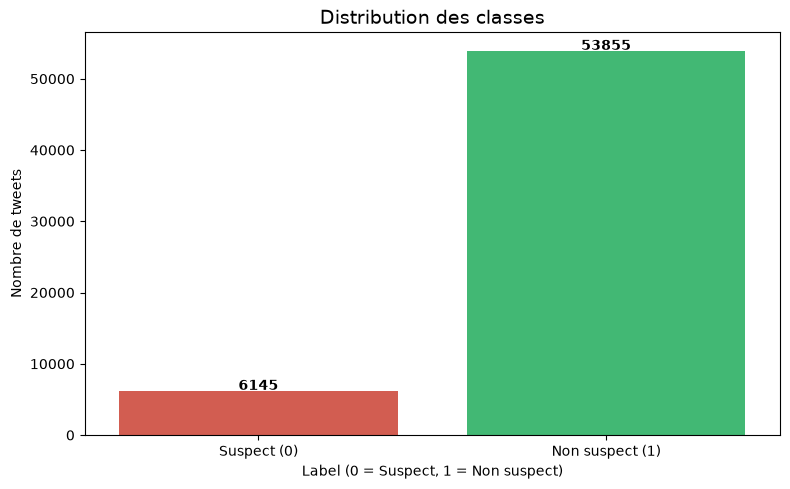

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Distribution des classes', fontsize=14)
plt.xlabel('Label (0 = Suspect, 1 = Non suspect)')
plt.ylabel('Nombre de tweets')
plt.xticks([0, 1], ['Suspect (0)', 'Non suspect (1)'])
for i, v in enumerate(df['label'].value_counts().sort_index()):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/distribution_classes.png')
plt.show()

Statistiques sur la longueur des tweets:
         count       mean        std  min   25%   50%    75%    max
label                                                              
0       6145.0  86.645566  35.967343  9.0  57.0  87.0  120.0  186.0
1      53855.0  72.277727  35.872189  6.0  43.0  67.0  100.0  168.0


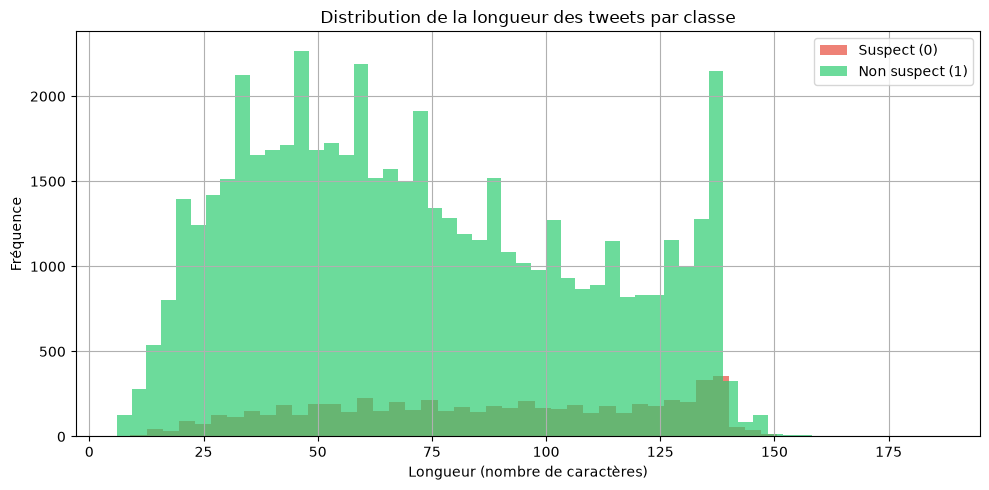

In [5]:
df['longueur'] = df['message'].apply(len)

print("Statistiques sur la longueur des tweets:")
print(df.groupby('label')['longueur'].describe())

plt.figure(figsize=(10, 5))
df[df['label'] == 0]['longueur'].hist(bins=50, alpha=0.7, color='#e74c3c', label='Suspect (0)')
df[df['label'] == 1]['longueur'].hist(bins=50, alpha=0.7, color='#2ecc71', label='Non suspect (1)')
plt.title('Distribution de la longueur des tweets par classe')
plt.xlabel('Longueur (nombre de caractères)')
plt.ylabel('Fréquence')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/longueur_tweets.png')
plt.show()

In [7]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['message_clean'] = df['message'].apply(preprocess)
df[['message', 'message_clean']].head(5)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OUATTARA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\OUATTARA\AppData\Roaming\nltk_data...


,message,message_clean
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",thats bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,@Kenichan I dived many times for the ball. Man...,dived many time ball managed save rest go bound
3,my whole body feels itchy and like its on fire,whole body feel itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving im mad cant see


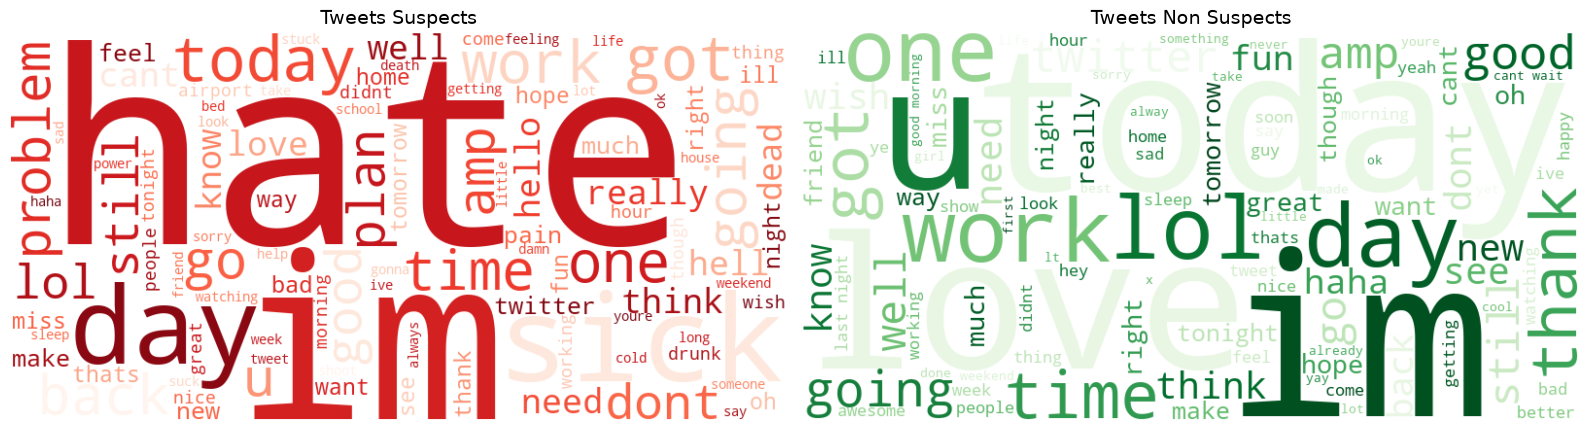

In [8]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, title, color) in enumerate([(0, 'Tweets Suspects', 'Reds'), 
                                             (1, 'Tweets Non Suspects', 'Greens')]):
    text = ' '.join(df[df['label'] == label]['message_clean'])
    wc = WordCloud(width=800, height=400, background_color='white', 
                   colormap=color, max_words=100).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(title, fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../reports/wordcloud.png')
plt.show()

In [ ]:
df[['message_clean', 'label']].to_csv('../data/processed/tweets_clean.csv', index=False)
print("Données prétraitées sauvegardées !")
print(f"Shape: {df.shape}")

Données prétraitées sauvegardées !
Shape: (60000, 4)


: 